In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


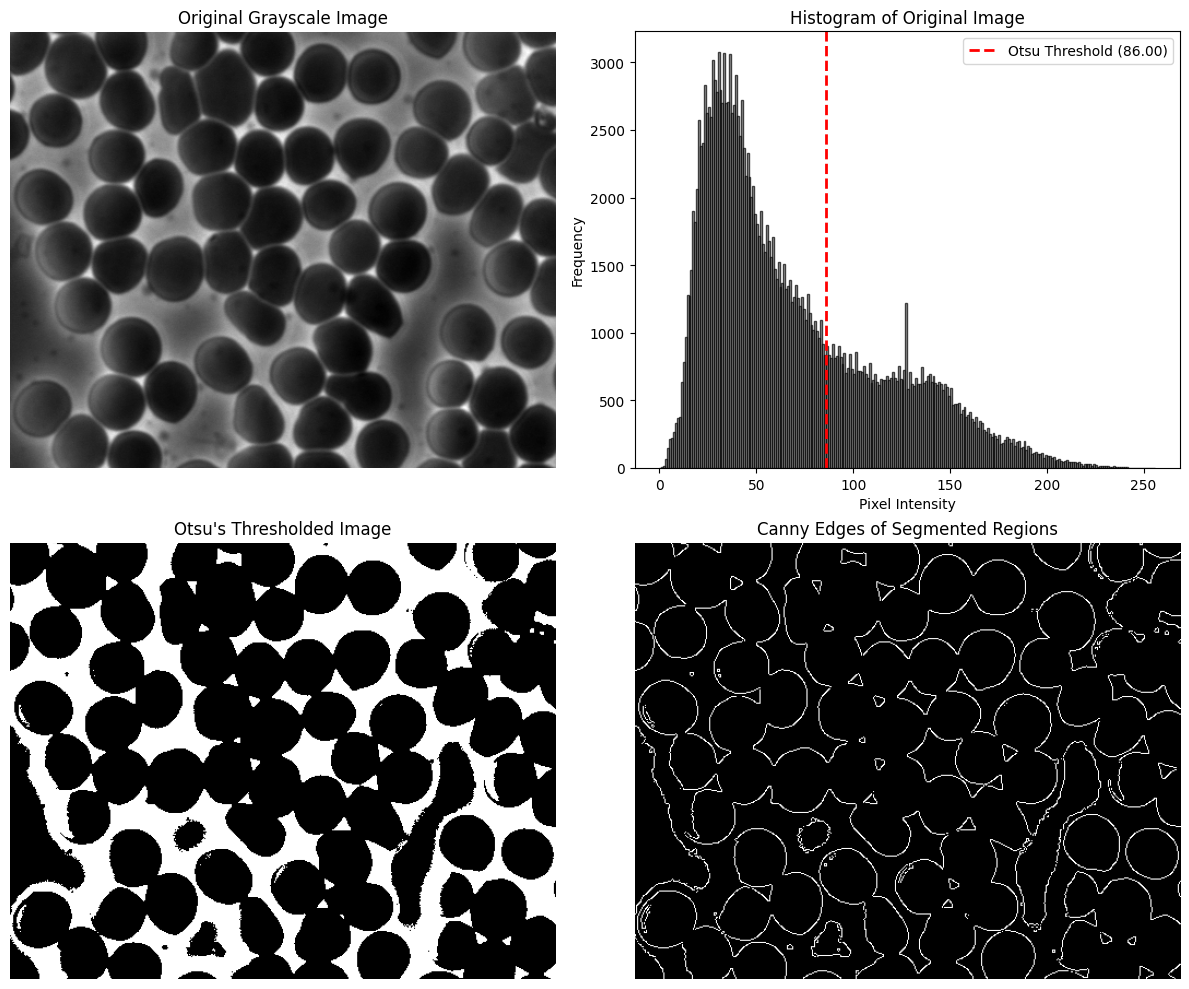

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

workpath = '/content/drive/MyDrive/DigitalImageProcessing/'
image_path = workpath + 'Data/rbc2.png'

# Load the grayscale image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not read image at {image_path}")
else:
    # Apply Otsu's thresholding
    ret, otsu_thresh_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Extract edges of segmented regions using Canny Edge Operator
    # 100 and 200 are standard hysteresis thresholds; adjust as needed
    canny_edges = cv2.Canny(otsu_thresh_img, 100, 200)

    # Display the results in a 2x2 subplot grid
    plt.figure(figsize=(12, 10))

    # 1. Original Grayscale Image
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    # 2. Histogram with Otsu Threshold
    plt.subplot(2, 2, 2)
    # Flatten the image to 1D array for histogram calculation
    plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7, edgecolor='black')
    # Plot vertical red line at optimal threshold
    plt.axvline(x=ret, color='red', linestyle='--', linewidth=2, label=f'Otsu Threshold ({ret:.2f})')
    plt.title('Histogram of Original Image')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()

    # 3. Otsu Thresholded Image
    plt.subplot(2, 2, 3)
    plt.imshow(otsu_thresh_img, cmap='gray')
    plt.title(f'Otsu\'s Thresholded Image')
    plt.axis('off')

    # 4. Canny Edges of Segmented Regions
    plt.subplot(2, 2, 4)
    plt.imshow(canny_edges, cmap='gray')
    plt.title('Canny Edges of Segmented Regions')
    plt.axis('off')

    plt.tight_layout()
    plt.show()



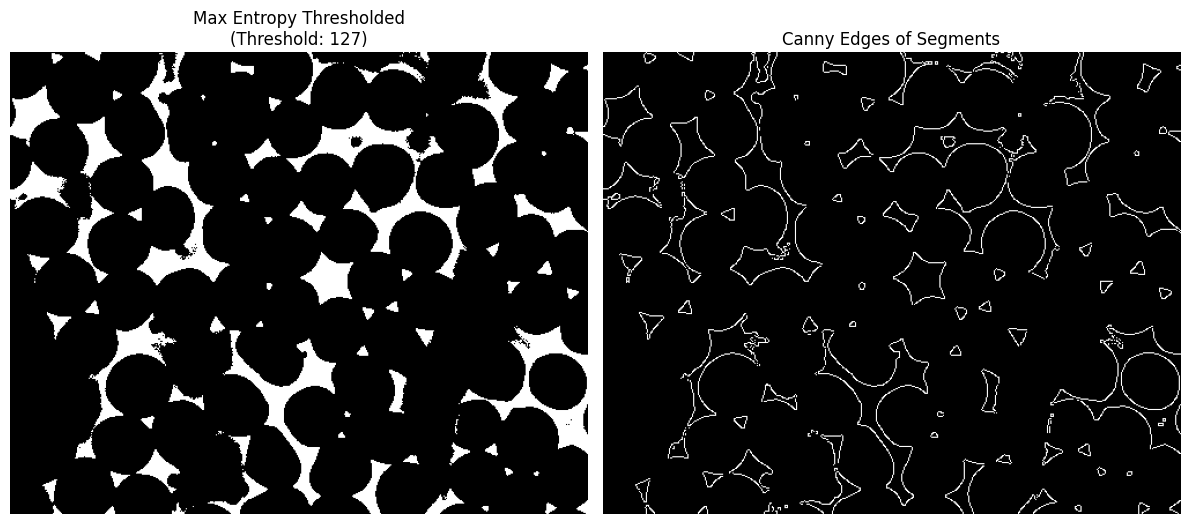

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define entropy thresholding function
def calculate_maximum_entropy_threshold(img):
    # Calculate normalized histogram (probability distribution)
    hist, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    hist = hist.astype(float) / hist.sum()

    # Cumulative probability sums (P)
    P = np.cumsum(hist)

    # Avoid log(0) issues by adding tiny epsilon to zero values safely
    eps = 1e-12
    hist = np.where(hist == 0, eps, hist)

    # Compute entropy for background (H_back) and foreground (H_fore)
    H_back = np.zeros(256)
    H_fore = np.zeros(256)

    for t in range(1, 255):
        if P[t] > 0 and P[t] < 1:
            # Slice distributions and calculate foreground/background entropy
            b_prob = hist[:t] / P[t]
            H_back[t] = -np.sum(b_prob * np.log2(b_prob))

        if (1 - P[t]) > 0 and (1 - P[t]) < 1:
            f_prob = hist[t:] / (1 - P[t])
            H_fore[t] = -np.sum(f_prob * np.log2(f_prob))

    total_entropy = H_back + H_fore

    # Set boundaries to -inf to avoid picking edge cases 0 or 255 trivially
    total_entropy[0] = -np.inf
    total_entropy[255] = -np.inf

    # Return optimal threshold t that maximizes entropy
    return int(np.argmax(total_entropy))

# Define workpath as it was in previous cells
workpath = '/content/drive/MyDrive/DigitalImageProcessing/'

# Make sure to update the image_path to point to your valid file locally or in Colab
image_path = workpath + 'Data/rbc2.png'

# Load the grayscale image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not read image at {image_path}")
else:
    # 1. Apply Maximum Entropy Thresholding
    optimal_thresh = calculate_maximum_entropy_threshold(img)
    ret, entropy_thresh_img = cv2.threshold(img, optimal_thresh, 255, cv2.THRESH_BINARY)

    # 2. Extract edges of segmented regions using Canny Edge Operator
    canny_low = int(optimal_thresh * 0.5)
    canny_high = int(optimal_thresh)
    canny_edges = cv2.Canny(entropy_thresh_img, canny_low, canny_high)

    # 3. Display the Original, Segmented, Histogram, and Edge images
    # Display the results in a 2x2 subplot grid
    plt.figure(figsize=(12, 10))

    # Thresholded Image
    plt.subplot(2, 2, 1)
    plt.imshow(entropy_thresh_img, cmap='gray')
    plt.title(f'Max Entropy Thresholded\n(Threshold: {optimal_thresh})')
    plt.axis('off')

    # Canny Edges
    plt.subplot(2, 2, 2)
    plt.imshow(canny_edges, cmap='gray')
    plt.title('Canny Edges of Segments')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

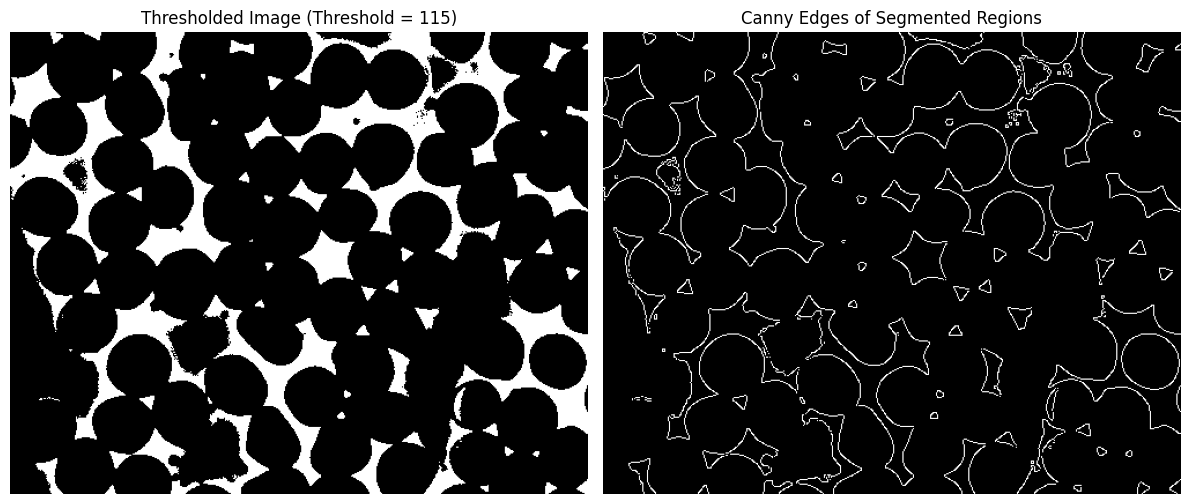

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

workpath = '/content/drive/MyDrive/DigitalImageProcessing/'
image_path = workpath + 'Data/rbc2.png'

# Load the grayscale image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not read image at {image_path}")
else:
    # Apply fixed thresholding at 115
    thresh_value = 115
    ret, thresh_img = cv2.threshold(img, thresh_value, 255, cv2.THRESH_BINARY)

    # Extract edges of segmented regions using Canny Edge Operator
    canny_edges = cv2.Canny(thresh_img, 100, 200)

    # Display the results in a 2x2 subplot grid
    # Display the results in a 2x2 subplot grid
    plt.figure(figsize=(12, 10))


    # 3. Thresholded Image
    plt.subplot(2, 2, 1)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'Thresholded Image (Threshold = {thresh_value})')
    plt.axis('off')

    # 4. Canny Edges of Segmented Regions
    plt.subplot(2, 2, 2)
    plt.imshow(canny_edges, cmap='gray')
    plt.title('Canny Edges of Segmented Regions')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
